# Ad Funnel Optimization: Click & Conversion Prediction using Machine Learning

## Business Problem

Digital advertising platforms aim to optimize performance across the full funnel:

- Impression → Click → Conversion

This project analyzes campaign-level data to:
- predict conversion likelihood
- identify key drivers of ad performance

The goal is to improve targeting, reduce wasted spend, and maximize return on ad spend (ROAS).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("KAG_conversion_data.csv")

df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [11]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset: (1143, 11)

Columns:
['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']

Data types:
ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                        str
gender                     str
interest                 int64
Impressions              int64
Clicks                   int64
Spent                  float64
Total_Conversion         int64
Approved_Conversion      int64
dtype: object

Missing values:
ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64


In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest', 'impressions', 'clicks', 'spent', 'total_conversion', 'approved_conversion']


In [15]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [17]:
df.describe()

,ad_id,xyz_campaign_id,fb_campaign_id,interest,impressions,clicks,spent,total_conversion,approved_conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,1067.382327,133783.989501,32.766404,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,1.939928e+05,121.629393,20500.308622,26.952131,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,7.087460e+05,916.000000,103916.000000,2.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,936.000000,115716.000000,16.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,1.121185e+06,1178.000000,144549.000000,25.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,1.121804e+06,1178.000000,144657.500000,31.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,1.314415e+06,1178.000000,179982.000000,114.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000


In [19]:
print("Unique age values:", sorted(df["age"].unique()))
print("Unique gender values:", df["gender"].unique())
print("Number of unique interests:", df["interest"].nunique())

Unique age values: ['30-34', '35-39', '40-44', '45-49']
Unique gender values: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
Number of unique interests: 40


In [21]:
# Avoid division by zero by replacing 0 with NaN temporarily
df["ctr"] = df["clicks"] / df["impressions"].replace(0, np.nan)
df["conversion_rate"] = df["total_conversion"] / df["clicks"].replace(0, np.nan)
df["approved_conversion_rate"] = df["approved_conversion"] / df["clicks"].replace(0, np.nan)

# Fill NaN results from division by zero with 0
df["ctr"] = df["ctr"].fillna(0)
df["conversion_rate"] = df["conversion_rate"].fillna(0)
df["approved_conversion_rate"] = df["approved_conversion_rate"].fillna(0)

df[["impressions", "clicks", "ctr", "total_conversion", "conversion_rate"]].head()

,impressions,clicks,ctr,total_conversion,conversion_rate
0,7350,1,0.000136,2,2.0
1,17861,2,0.000112,2,1.0
2,693,0,0.000000,1,0.0
3,4259,1,0.000235,1,1.0
4,4133,1,0.000242,1,1.0


In [27]:
df["high_ctr"] = (df["ctr"] > df["ctr"].median()).astype(int)

df["high_conversion"] = (
    df["conversion_rate"] > df["conversion_rate"].median()
).astype(int)

print("High CTR class distribution:")
print(df["high_ctr"].value_counts())

print("\nHigh Conversion class distribution:")
print(df["high_conversion"].value_counts())

High CTR class distribution:
high_ctr
0    572
1    571
Name: count, dtype: int64

High Conversion class distribution:
high_conversion
0    575
1    568
Name: count, dtype: int64


In [25]:
df["gender"] = df["gender"].map({"M": 0, "F": 1})

print(df["gender"].value_counts(dropna=False))

gender
0    592
1    551
Name: count, dtype: int64


In [35]:
def age_to_midpoint(age_range):
    start, end = age_range.split('-')
    return (int(start) + int(end)) / 2

df["age_mid"] = df["age"].apply(age_to_midpoint)

In [37]:
features = ["age_mid", "gender", "interest", "impressions", "spent"]

X = df[features].copy()
y_conv = df["high_conversion"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_conv,
    test_size=0.2,
    random_state=42,
    stratify=y_conv
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
## MODEL 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [49]:
## MODEL 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [51]:
from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Accuracy: 0.6637554585152838
Random Forest Accuracy: 0.8558951965065502


In [53]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic:\n", cm_log)
print("Random Forest:\n", cm_rf)

Logistic:
 [[56 59]
 [18 96]]
Random Forest:
 [[101  14]
 [ 19  95]]


In [55]:
from sklearn.metrics import classification_report

print("Logistic:\n", classification_report(y_test, y_pred_log))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic:
               precision    recall  f1-score   support

           0       0.76      0.49      0.59       115
           1       0.62      0.84      0.71       114

    accuracy                           0.66       229
   macro avg       0.69      0.66      0.65       229
weighted avg       0.69      0.66      0.65       229

Random Forest:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       115
           1       0.87      0.83      0.85       114

    accuracy                           0.86       229
   macro avg       0.86      0.86      0.86       229
weighted avg       0.86      0.86      0.86       229



## INTERPRETATION

Logistic Regression performed reasonably but showed bias toward predicting high-conversion campaigns, with low recall for the negative class. Random Forest significantly improved performance by capturing nonlinear relationships, achieving balanced precision and recall across both classes. This suggests that campaign performance depends on complex interactions between features such as interest segments and spend, which tree-based models handle better.

Mathematically, there are nonlinear relationships and
interactions between:
interest,
spend,
impressions

In [57]:
from sklearn.metrics import roc_auc_score, roc_curve

log_auc = roc_auc_score(y_test, y_prob_log)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Logistic AUC:", log_auc)
print("RF AUC:", rf_auc)

Logistic AUC: 0.6496567505720824
RF AUC: 0.9411899313501144


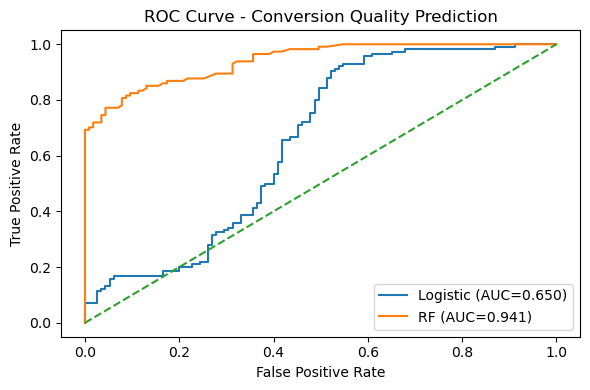

In [59]:
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={log_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={rf_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Conversion Quality Prediction")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curve_conversion.png")
plt.show()

## INTERPRETATION

The ROC curve shows that Random Forest significantly outperforms Logistic Regression, with an AUC of 0.94 compared to 0.65. This indicates that Random Forest can effectively distinguish between high- and low-performing campaigns, while Logistic Regression struggles due to its linear assumptions. This suggests that campaign performance depends on nonlinear interactions between features such as interest segments and spend.

In [69]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance

,feature,importance
4,spent,0.524498
3,impressions,0.282353
2,interest,0.099106
0,age_mid,0.073637
1,gender,0.020405


## Feature Importance Analysis

To better understand the drivers of campaign performance, I examined feature importance from the Random Forest model. The results show a clear hierarchy in how different variables contribute to predicting conversion quality.

The most important feature is **ad spend**, accounting for approximately 52% of the model’s predictive power. This indicates that budget allocation is the primary driver of campaign performance. Higher spend likely enables better delivery optimization, increased reach, and improved auction competitiveness, all of which contribute to stronger conversion outcomes. In practice, this suggests that scaling investment in well-performing segments is critical for maximizing results.

The second most important feature is **impressions** (approximately 28%). This reflects the importance of exposure—campaigns that reach more users have more opportunities to generate conversions. However, impressions are notably less important than spend, indicating that simply increasing reach is not sufficient. Instead, how budget is allocated and optimized plays a more significant role than raw volume alone.

The **interest** feature contributes around 10% of the importance, suggesting that audience targeting still plays a meaningful but secondary role. Different interest segments respond differently to ads, and selecting the right audience can improve performance. However, compared to spend and impressions, targeting alone is not the dominant factor.

Demographic variables such as **age** (7%) and **gender** (2%) have relatively low importance. This suggests that traditional demographic segmentation provides limited predictive value in this context. Instead, behavioral and campaign-level factors are far more influential in determining outcomes.

Overall, the results show that **campaign performance is primarily driven by budget and delivery scale rather than demographic characteristics**. Spend and impressions together account for over 80% of the model’s predictive power, highlighting the importance of optimizing budget allocation and campaign execution. 

From a business perspective, this implies that advertising strategies should prioritize:
- efficient budget allocation across campaigns
- scaling high-performing segments
- optimizing delivery mechanisms

rather than relying heavily on demographic targeting alone. This aligns with how modern advertising platforms such as TikTok, Meta, and Google Ads operate, where algorithmic optimization and budget allocation are key drivers of performance.

## PREDICTION & RECOMMENDATION

In [74]:
y_reg = df["total_conversion"]

In [76]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [78]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_lr = lr_model.predict(X_test_r)

In [80]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_r, y_train_r)

y_pred_rf = rf_reg.predict(X_test_r)

In [98]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_mse = mean_squared_error(y_test_r, y_pred_lr)
rf_mse = mean_squared_error(y_test_r, y_pred_rf)

lr_rmse = np.sqrt(lr_mse)
rf_rmse = np.sqrt(rf_mse)

print("Linear Regression RMSE:", lr_rmse)
print("RF RMSE:", rf_rmse)

print("Linear Regression R2:", r2_score(y_test_r, y_pred_lr))
print("RF R2:", r2_score(y_test_r, y_pred_rf))

Linear Regression RMSE: 1.858654754927888
RF RMSE: 1.9633238959794732
Linear Regression R2: 0.8169280117692942
RF R2: 0.7957282314288023


In [100]:
spend_range = np.linspace(
    df["spent"].min(),
    df["spent"].max(),
    50
)

avg_features = X.mean().to_dict()

results = []

for s in spend_range:
    temp = avg_features.copy()
    temp["spent"] = s
    
    pred = rf_reg.predict(pd.DataFrame([temp]))[0]
    
    results.append((s, pred))

curve_df = pd.DataFrame(results, columns=["spent", "predicted_conversion"])

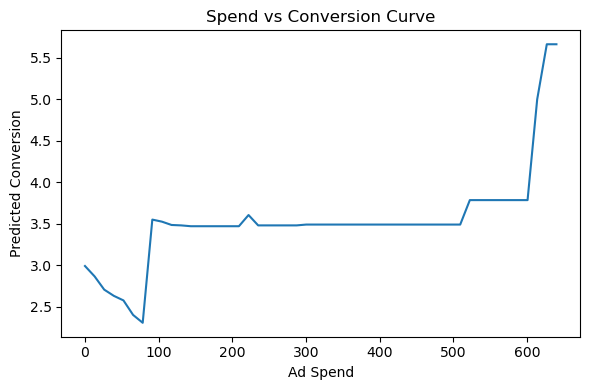

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(curve_df["spent"], curve_df["predicted_conversion"])

plt.xlabel("Ad Spend")
plt.ylabel("Predicted Conversion")
plt.title("Spend vs Conversion Curve")

plt.tight_layout()
plt.savefig("spend_vs_conversion.png")
plt.show()

In [104]:
curve_df["delta_conversion"] = curve_df["predicted_conversion"].diff()
curve_df["delta_spend"] = curve_df["spent"].diff()

curve_df["marginal_return"] = curve_df["delta_conversion"] / curve_df["delta_spend"]

In [106]:
threshold = curve_df["marginal_return"].median()

sweet_spot = curve_df[curve_df["marginal_return"] > threshold]

print(sweet_spot.head())

         spent  predicted_conversion  delta_conversion  delta_spend  \
7    91.421428                 3.550             1.245    13.060204   
17  222.023469                 3.605             0.135    13.060204   
23  300.384693                 3.490             0.010    13.060204   
40  522.408162                 3.785             0.295    13.060204   
47  613.829590                 5.000             1.215    13.060204   

    marginal_return  
7          0.095328  
17         0.010337  
23         0.000766  
40         0.022588  
47         0.093031  


In [108]:
segment_perf = df.groupby("interest").agg({
    "spent": "mean",
    "total_conversion": "mean",
    "conversion_rate": "mean"
}).reset_index()

segment_perf = segment_perf.sort_values(
    by="conversion_rate",
    ascending=False
)

segment_perf.head()

,interest,spent,total_conversion,conversion_rate
3,15,50.926667,3.823529,0.429320
37,112,69.114286,7.571429,0.377939
29,104,77.584000,8.600000,0.331063
15,28,62.859804,2.862745,0.294779
4,16,57.749357,2.935714,0.294444


In [110]:
recommendations = []

top_segments = segment_perf.head(3)

for _, row in top_segments.iterrows():
    msg = f"""
    Segment {row['interest']} shows strong performance with 
    avg conversion rate {row['conversion_rate']:.2f}.
    Recommend increasing budget allocation.
    """
    recommendations.append(msg)

recommendations

['\n    Segment 15.0 shows strong performance with \n    avg conversion rate 0.43.\n    Recommend increasing budget allocation.\n    ',
 '\n    Segment 112.0 shows strong performance with \n    avg conversion rate 0.38.\n    Recommend increasing budget allocation.\n    ',
 '\n    Segment 104.0 shows strong performance with \n    avg conversion rate 0.33.\n    Recommend increasing budget allocation.\n    ']